# **feature selection + Classifier**

- feature selection
   - 모델에 필요한 변수(컬럼)만 선택하는 것
   - 왜 중요한가?
      - 성능 향상 : 불필요한 feature가 있으면 노이즈↑ > 중요한 정보만 학습시켜 정확도 ↑
      - Generalization : feature가 너무 많으면 모델이 쓸데없는 것까지 외움 > feature를 줄여 Overfit 방지
      - 학습 속도 향상 : feature를 줄이면 속도 향상 + 효율적
    - 순서
       1. label encoding
       2. 불필요한 컬럼 drop
       3. 결측치 확인 및 제거
       4. label 갯수 확인



---



- google drive mount

In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


- csv 파일 읽기

In [32]:
import pandas as pd
import numpy as np

path = '/content/drive/MyDrive/Colab Notebooks/4week/titanic.csv'

df = pd.read_csv(path)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


- 컬럼명 확인
   - PassengerId : 승객 고유 번호
   - Survived : 생존 여부 (정답y)
   - Pclass : 객실 등급
   - Name : 승객 이름
   - Sex : 성별
   - Age : 나이
   - SibSp : 함께 탑승한 형제/배우자 수
   - Parch : 함께 탑승한 부모/자식 수
   - Ticket : 티켓 번호
   - Fare : 요금
   - Cabin : 객실 번호
   - Embarked : 승선 항구 (S = Southampton / C = Cherbourg / Q = Queenstown)

In [47]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

# **< feature selection >**
  1. label encoding
     - 모델은 숫자만 계산할 수 있기 때문에, 문자 데이터를 수치로 변환하는 과정

In [45]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

# 분류에 필요한 정보는 drop하지 않고 숫자로 인코딩
df['Sex'] =le.fit_transform(df['Sex'])
df['Embarked'] =le.fit_transform(df['Embarked'])

2. drop + X/y 컬럼 지정
   - drop : 데이터에서 필요 없는 컬럼(열)을 삭제하는 것
   - 'Survived' : 정답이라서 학습 단계에서 사용하지 않기 때문에 제거
   - 'Name', 'Ticket', 'Cabin' : 학습에 필요하지 않은 정보라서 제거

In [46]:
# y값(정답) 지정
y=df['Survived']
y.value_counts()
y

# X값(데이터) 지정 + 중요하지 않은 컬럼 drop
X=df.drop(['Survived', 'Name', 'Ticket', 'Cabin'],axis=1)
X.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,3,1,22.0,1,0,7.2500,2
1,2,1,0,38.0,1,0,71.2833,0
2,3,3,0,26.0,0,0,7.9250,2
3,4,1,0,35.0,1,0,53.1000,2
4,5,3,1,35.0,0,0,8.0500,2


3. 결측치 확인 및 제거
   - Why? 모델은 Nah(빈 값)을 처리하지 못 하기 때문에 제거
   - 방법1 : 중요한 컬럼은 대체값으로 채운다 (ex. Avg)
   - 방법2 : 결측치가 너무 많은 컬럼은 drop

In [35]:
# 결측지 확인
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [36]:
# 결측치를 해당 칼럼의 평균값으로 대체
X['Age'] = X['Age'].fillna(X['Age'].mean())

# 결측치 삭제 : df_clean = df.dropna()
# *Cabin은 컬럼 자체를 drop했기 때문에 따로 결측치에 대한 처리 없음.

X.isnull().sum()

,0
PassengerId,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


4. label 갯수 확인
   - 클래스 분포 (데이터 균형) 확인

Text(0.5, 1.0, 'Label')

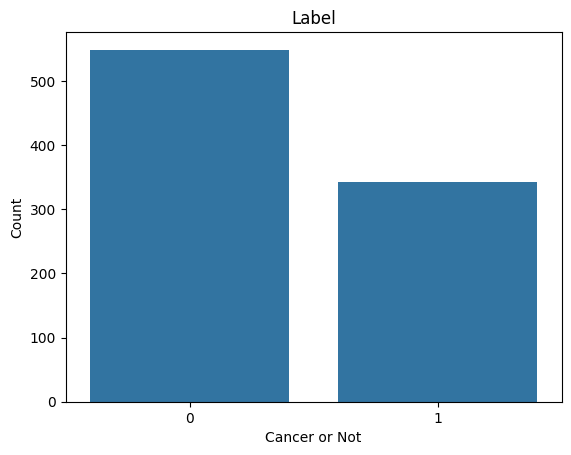

In [37]:
# 레이블 갯수 확인 (그래프)
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data = df, x="Survived")
plt.xlabel("Cancer or Not")
plt.ylabel("Count")
plt.title("Label")

In [38]:
# 레이블 갯수 확인 (숫자)
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


- train/test 데이터 분할 + 비율 설정

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.20,random_state=0)

- 모델 import + 평가방법 설정

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn import metrics
import matplotlib.pyplot as plt

- Logistic Regression Classifier

In [49]:
clf_lr = LogisticRegression(random_state=0)
clf_lr.fit(X_train, y_train)

pred_lr = clf_lr.predict(X_test)

print ("\n--- Logistic Regression Classifier ---")
print (accuracy_score(y_test, pred_lr))
print (confusion_matrix(y_test, pred_lr))


--- Logistic Regression Classifier ---
0.7821229050279329
[[91 19]
 [20 49]]


- MLP Classifier

In [55]:
clf_nn = MLPClassifier(random_state=0)
clf_nn.fit(X_train, y_train)

pred_nn = clf_nn.predict(X_test)

print ("\n--- Neural Network Classifier ---")
print (accuracy_score(y_test, pred_nn))
print (confusion_matrix(y_test, pred_nn))


--- Neural Network Classifier ---
0.6983240223463687
[[104   6]
 [ 48  21]]


- Decision Tree Classifier

In [50]:
clf_dt = DecisionTreeClassifier(random_state=0)
clf_dt.fit(X_train, y_train)

pred_dt = clf_dt.predict(X_test)

print ("\n--- Decision Tree Classifier ---")
print (accuracy_score(y_test, pred_dt))
print (confusion_matrix(y_test, pred_dt))


--- Decision Tree Classifier ---
0.7877094972067039
[[96 14]
 [24 45]]


- Random Forest Classifier

In [52]:
import warnings
warnings.filterwarnings('ignore')

print ("\n--- Radom Forest ---")
rf_clf = RandomForestClassifier(random_state=0)
rf_clf.fit(X_train, y_train)
pred = rf_clf.predict(X_test)
print(accuracy_score(y_test,pred))
print (confusion_matrix(y_test, pred))


--- Radom Forest ---
0.8603351955307262
[[105   5]
 [ 20  49]]


- KNN

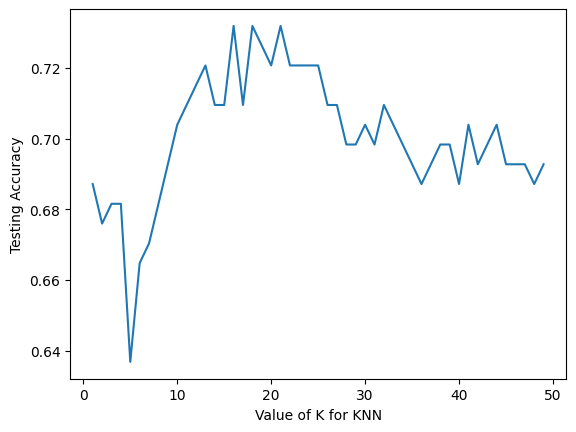

In [58]:
# K의 범위 설정 (k : 참고할 이웃(데이터) 개수)
# k = 15 : 새로운 데이터에 대해 가장 비슷한 15개의 데이터를 보고 판단
k_range = range(1, 50)
scores = []

# 각 K값에 대해 모델 학습 및 검증
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    scores.append(metrics.accuracy_score(y_test, y_pred))

# 결과 시각화
plt.plot(k_range, scores)
plt.xlabel('Value of K for KNN')
plt.ylabel('Testing Accuracy')
plt.show()